# When can you start copying the best managers — and does it even help?

**Season:** 2025/26 &nbsp;•&nbsp; **Question:** you finished outside the top 100K. You have weekly
data from ~1,000 managers who finished near the **top 1%**. When picking for the next 4–8
gameweeks, you'd only know what they did *up to last week*. So: (1) how early is a "currently
strong" manager genuinely skilled and not just lucky, and (2) once you trust them, does copying
**who they own** actually help you pick players — better than free, simple signals?

**The short answer (read this first).** The strong-manager group becomes trustworthy **early —
around Gameweek 6–8.** But copying their ownership was **never worth it**: their effective
ownership predicts the next few weeks' points no better than plain "how many managers own this
player at all," and barely better than "who scored most recently." And the tighter and more
elite you make the group, the **worse** the signal gets.

Everything below is a **link, not a cause** — this describes what predicts what over one season,
not a guaranteed result of any single transfer.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
os.makedirs('outputs/charts', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.edgecolor': '#888', 'xtick.color': '#555', 'ytick.color': '#555',
    'axes.labelcolor': '#333', 'text.color': '#222', 'font.family': 'DejaVu Sans',
})
GREY   = '#B7BEC7'
MUTED  = '#6C7A89'
GOOD   = '#3F9A56'   # good news / easier
BAD    = '#C0392B'   # bad news / loses
EO_C   = '#8E44AD'   # elite-cohort effective ownership
OWN_C  = '#4E79A7'   # plain whole-sample ownership
REC_C  = '#3F9A56'   # recent points

# reuse the analysis module (loads/caches the manager panel once -> fast, single source of truth)
sys.path.insert(0, 'analysis/elite_cohort_eo')
from eo_panel import build_panel, RANK, MIDS
print(f'reference managers: {len(MIDS)}')
panel4 = build_panel(4)
print(f'panel rows (N=4, playing players): {len(panel4):,}  |  decision GWs: {panel4.t.nunique()}')

loaded cache
players/gw: 38 GWs; managers: 1000
reference managers: 1000
panel rows (N=4, playing players): 6,786  |  decision GWs: 31


## 1. Early in the season, rank is almost pure luck

Start with the simplest possible picture: where do these managers actually rank at different points
in the season? Each curve below is the spread of overall ranks across the same ~1,000 managers, at
Gameweek 1, Gameweek 8, and the final Gameweek 38. (Rank is on a log scale — each step is 10× —
because the numbers run into the millions.)

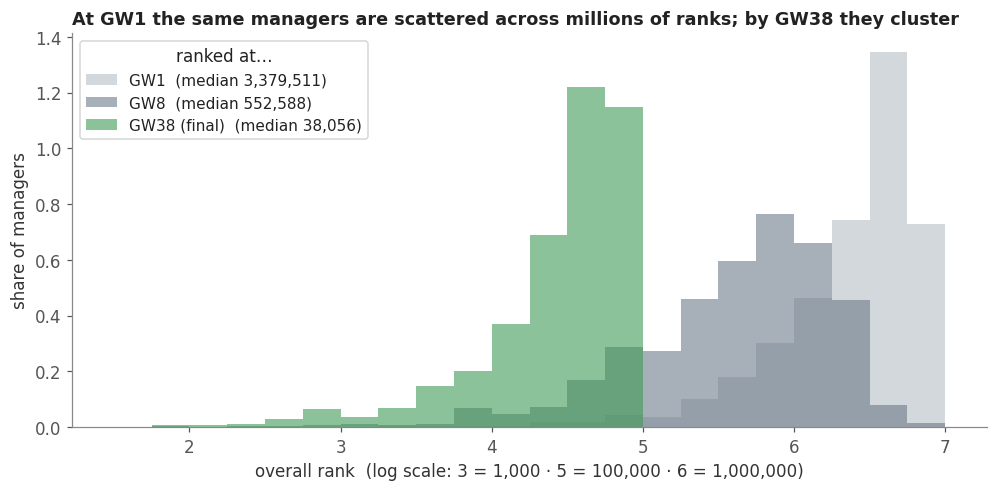

In [2]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))
for gw, col, lab in [(1, GREY, 'GW1'), (8, MUTED, 'GW8'), (38, GOOD, 'GW38 (final)')]:
    vals = np.array([RANK[m][gw] for m in MIDS if gw in RANK[m]], dtype=float)
    ax.hist(np.log10(vals), bins=np.arange(1.5, 7.2, 0.25), color=col, alpha=0.6,
            label=f'{lab}  (median {np.median(vals):,.0f})', density=True)
ax.set_xlabel('overall rank  (log scale: 3 = 1,000 · 5 = 100,000 · 6 = 1,000,000)')
ax.set_ylabel('share of managers')
ax.legend(fontsize=10, title='ranked at…')
ax.set_title('At GW1 the same managers are scattered across millions of ranks; by GW38 they cluster',
             loc='left', fontsize=11.5)
plt.tight_layout(); plt.savefig('outputs/charts/eo_01_rank_noise.png', bbox_inches='tight'); plt.show()

**Reading it:** at Gameweek 1 these eventual top-1% managers are smeared across the *entire* rank
range — some sit in the millions after one bad week. A single gameweek is mostly luck. As the season
goes on the whole group slides left (better) and bunches up. So "top 10K **right now**" means very
different things in September versus March.

## 2. The two raw ingredients: elite ownership, and points scored

Now the pieces we'll actually test. On the left: **effective ownership** — for each player, the share
of the strong-manager group that owns them. On the right: the points those same players go on to score
over the next 4 gameweeks. (Both are for players likely to start — ≥45 min/GW over their last 4 games.)

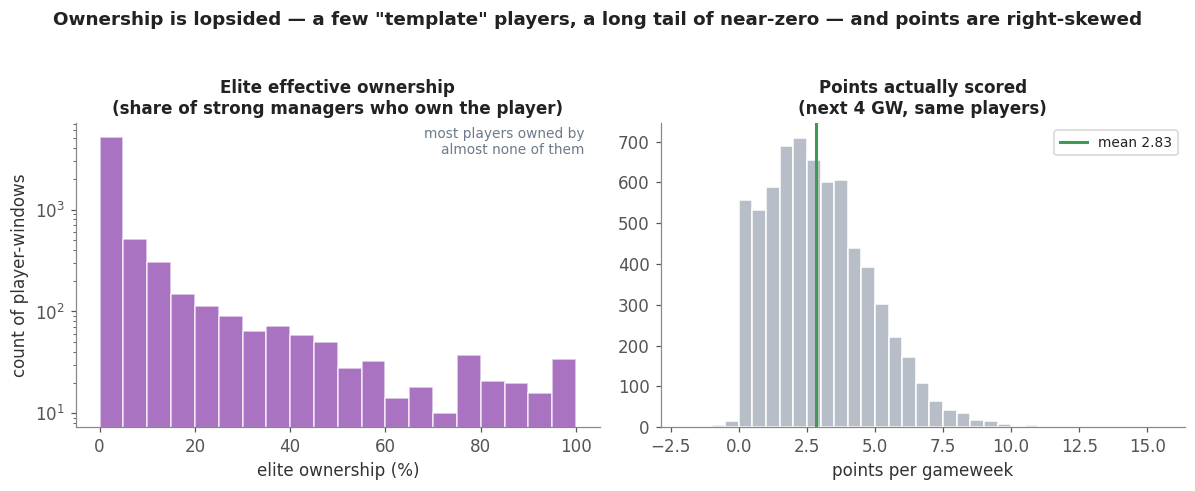

share of player-windows with <1% elite ownership: 54%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].hist(panel4['cohort_eo'] * 100, bins=np.arange(0, 101, 5), color=EO_C, alpha=0.75, edgecolor='white')
axes[0].set_title('Elite effective ownership\n(share of strong managers who own the player)', fontsize=11)
axes[0].set_xlabel('elite ownership (%)'); axes[0].set_ylabel('count of player-windows')
axes[0].set_yscale('log')
axes[0].text(0.97, 0.9, 'most players owned by\nalmost none of them', transform=axes[0].transAxes,
             ha='right', fontsize=9, color=MUTED)

axes[1].hist(panel4['fwd_mean'], bins=np.arange(-2, 16, 0.5), color=GREY, edgecolor='white')
axes[1].axvline(panel4['fwd_mean'].mean(), color=GOOD, lw=2, label=f"mean {panel4['fwd_mean'].mean():.2f}")
axes[1].set_title('Points actually scored\n(next 4 GW, same players)', fontsize=11)
axes[1].set_xlabel('points per gameweek'); axes[1].legend(fontsize=9)
fig.suptitle('Ownership is lopsided — a few "template" players, a long tail of near-zero — and points are right-skewed',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('outputs/charts/eo_02_ingredients.png', bbox_inches='tight'); plt.show()
print(f"share of player-windows with <1% elite ownership: {(panel4['cohort_eo']<0.01).mean():.0%}")

**Reading it:** elite ownership is heavily lopsided (note the log-scaled height) — a small number of
"template" players are owned by almost everyone strong, while most players are owned by hardly any of
them. Points are right-skewed as always: lots of quiet gameweeks, a few big hauls. The real question
is whether the left chart helps you predict the right one.

## 3. When do "strong managers" stop being lucky? Around Gameweek 6–8

Before copying anyone, you need the group to be genuinely skilled. Simple test: how well does a
manager's rank at one gameweek predict their rank **four gameweeks later**? A high, steady number means
the ordering is real, not noise. (1.0 = perfectly stable order; 0 = pure reshuffle.)

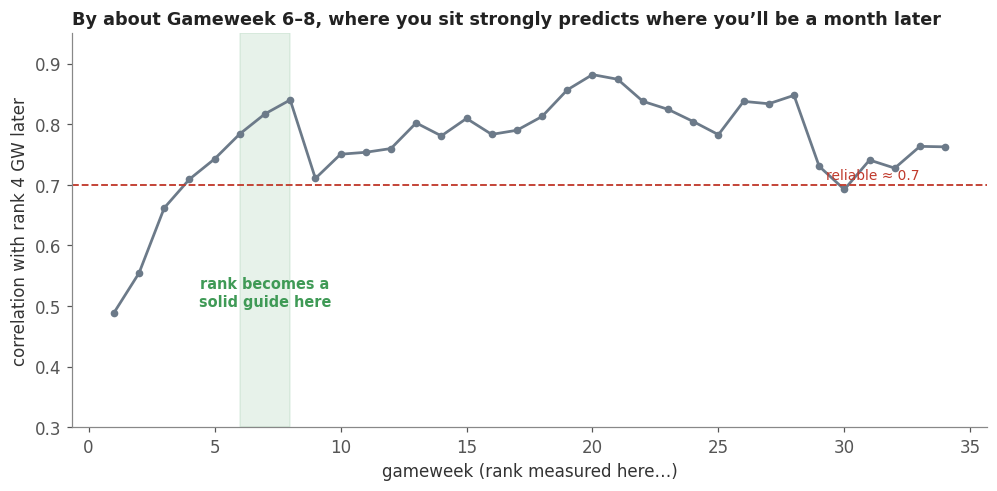

rho(t, t+4) at GW4,6,8: [np.float64(0.709), np.float64(0.784), np.float64(0.84)]


In [4]:
gws, rho4 = [], []
for t in range(1, 35):
    a = np.array([RANK[m].get(t, np.nan) for m in MIDS])
    b = np.array([RANK[m].get(t+4, np.nan) for m in MIDS])
    msk = ~np.isnan(a) & ~np.isnan(b)
    gws.append(t); rho4.append(spearmanr(a[msk], b[msk]).correlation)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.axvspan(6, 8, color=GOOD, alpha=0.12)
ax.plot(gws, rho4, '-o', color=MUTED, ms=4, lw=1.8)
ax.axhline(0.7, color=BAD, ls='--', lw=1.2)
ax.text(33, 0.71, 'reliable ≈ 0.7', color=BAD, ha='right', fontsize=9)
ax.text(7, 0.5, 'rank becomes a\nsolid guide here', color=GOOD, ha='center', fontsize=9.5, fontweight='bold')
ax.set_ylim(0.3, 0.95)
ax.set_xlabel('gameweek (rank measured here…)'); ax.set_ylabel('correlation with rank 4 GW later')
ax.set_title('By about Gameweek 6–8, where you sit strongly predicts where you’ll be a month later',
             loc='left', fontsize=11.5)
plt.tight_layout(); plt.savefig('outputs/charts/eo_03_rank_persistence.png', bbox_inches='tight'); plt.show()
print('rho(t, t+4) at GW4,6,8:', [round(rho4[gws.index(g)],3) for g in (4,6,8)])

**Reading it:** the line climbs fast out of the early-season noise and settles around **0.8 by
Gameweek 6–8** — from there, a manager's current rank is a dependable guide to their rank a month
later. So the *reference group itself* is trustworthy early. That makes the next result the surprising
one: the group is real, but copying it still doesn't help.

## 4. Does elite ownership predict points? A little — but weakly

Here's the core relationship: do players owned by more of the strong managers actually score more over
the next 4 gameweeks? The left panel is every player-window; the right groups players by how widely the
elite own them.

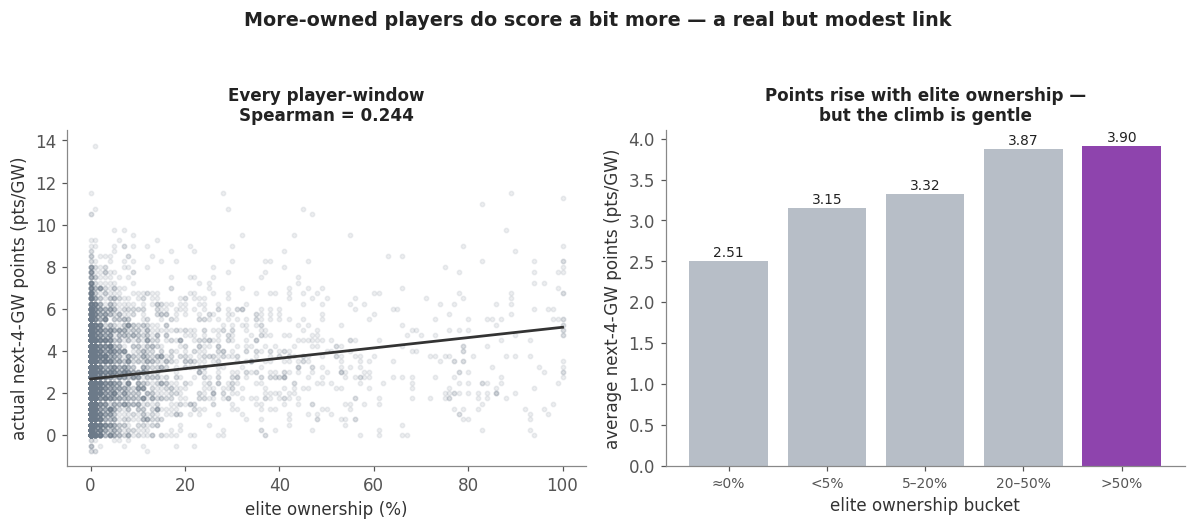

eo_bin
≈0%       2.51
<5%       3.15
5–20%     3.32
20–50%    3.87
>50%      3.90
Name: fwd_mean, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
ax.scatter(panel4['cohort_eo']*100, panel4['fwd_mean'], s=8, alpha=0.12, color=MUTED)
z = np.polyfit(panel4['cohort_eo']*100, panel4['fwd_mean'], 1)
xs = np.linspace(0, 100, 50); ax.plot(xs, np.polyval(z, xs), color='#333', lw=1.8)
rho = spearmanr(panel4['cohort_eo'], panel4['fwd_mean']).correlation
ax.set_title(f'Every player-window\nSpearman = {rho:.3f}', fontsize=11)
ax.set_xlabel('elite ownership (%)'); ax.set_ylabel('actual next-4-GW points (pts/GW)')

ax2 = axes[1]
bins = [-0.001, 0.01, 0.05, 0.20, 0.50, 1.01]
labs = ['≈0%', '<5%', '5–20%', '20–50%', '>50%']
panel4['eo_bin'] = pd.cut(panel4['cohort_eo'], bins=bins, labels=labs)
bmean = panel4.groupby('eo_bin', observed=True)['fwd_mean'].mean()
cols = [GREY, GREY, GREY, GREY, EO_C]
ax2.bar(range(len(bmean)), bmean.values, color=cols[:len(bmean)])
ax2.set_xticks(range(len(bmean))); ax2.set_xticklabels(list(bmean.index), fontsize=9)
ax2.set_xlabel('elite ownership bucket'); ax2.set_ylabel('average next-4-GW points (pts/GW)')
ax2.set_title('Points rise with elite ownership —\nbut the climb is gentle', fontsize=11)
for i, v in enumerate(bmean.values): ax2.text(i, v+0.05, f'{v:.2f}', ha='center', fontsize=9)
fig.suptitle('More-owned players do score a bit more — a real but modest link',
             fontsize=12.5, fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('outputs/charts/eo_04_eo_vs_points.png', bbox_inches='tight'); plt.show()
print(bmean.round(2))

**Reading it:** there's a real upward tilt — the most widely-owned players do score more — but it's
gentle (Spearman ≈ 0.24), and the scatter cloud is enormous. Elite ownership carries *some* signal.
The question that decides everything is whether it beats the free alternatives.

## 5. The headline: elite ownership loses to plain popularity — and free recent form nearly ties it

Now the decisive comparison. Each bar is how well a signal, known *last week*, ranks players by the
points they'll score over the next 4 gameweeks (higher = better shortlist). We line up **elite
ownership** against two things that cost you nothing: **plain popularity** (how many of *all* the
managers own the player) and **recent points**.

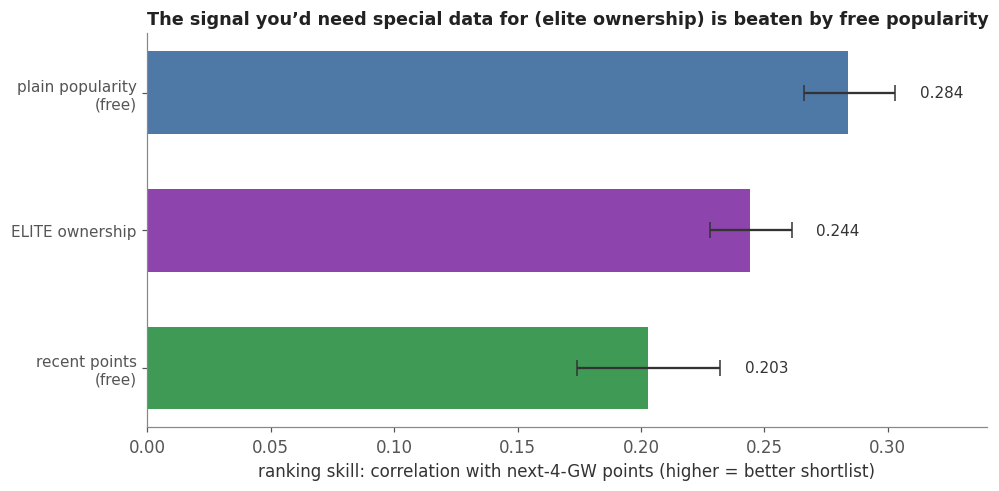

In [6]:
# ---- verified numbers (source: analysis-stage walk-forward test, GW-block bootstrap, N=4) ----
# analysis/elite_cohort_eo/eo_model.py : Spearman(signal, forward points) among playing players.
names  = ['plain popularity\n(free)', 'ELITE ownership', 'recent points\n(free)']
vals   = [0.284, 0.244, 0.203]
los    = [0.266, 0.228, 0.174]
his    = [0.303, 0.261, 0.232]
cols   = [OWN_C, EO_C, REC_C]

fig, ax = plt.subplots(figsize=(9.2, 4.6))
y = np.arange(3)[::-1]
ax.barh(y, vals, color=cols, height=0.6)
ax.errorbar(vals, y, xerr=[np.array(vals)-np.array(los), np.array(his)-np.array(vals)],
            fmt='none', ecolor='#333', capsize=5)
for yi, v, h in zip(y, vals, his): ax.text(h+0.010, yi, f'{v:.3f}', va='center', fontsize=10, color='#333')
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('ranking skill: correlation with next-4-GW points (higher = better shortlist)')
ax.set_xlim(0, 0.34)
ax.set_title('The signal you’d need special data for (elite ownership) is beaten by free popularity',
             loc='left', fontsize=11.5)
plt.tight_layout(); plt.savefig('outputs/charts/eo_05_ranking_skill.png', bbox_inches='tight'); plt.show()

**Reading it:** **plain popularity (0.284) beats elite ownership (0.244)** — and this gap held in every
robustness check we ran, with the confidence intervals (the thin bars = the range the true value
plausibly sits in) clearly apart. Elite ownership edges *recent points* by only a hair (0.244 vs 0.203),
and even that thin edge vanishes over an 8-gameweek window. Put plainly: knowing which *elite* managers
own a player tells you nothing you couldn't get, for free, from how popular the player already is.

## 6. The twist: the more elite the group, the worse it gets — and it never "switches on"

You might think a *purer* elite group would be sharper. The opposite is true. The left panel shows elite
ownership's ranking skill **minus** plain popularity's, for four ways of defining "elite." Every bar is
below zero — elite ownership always loses — and it loses *most* for the tightest groups. The right panel
shows there's no magic gameweek where it starts winning.

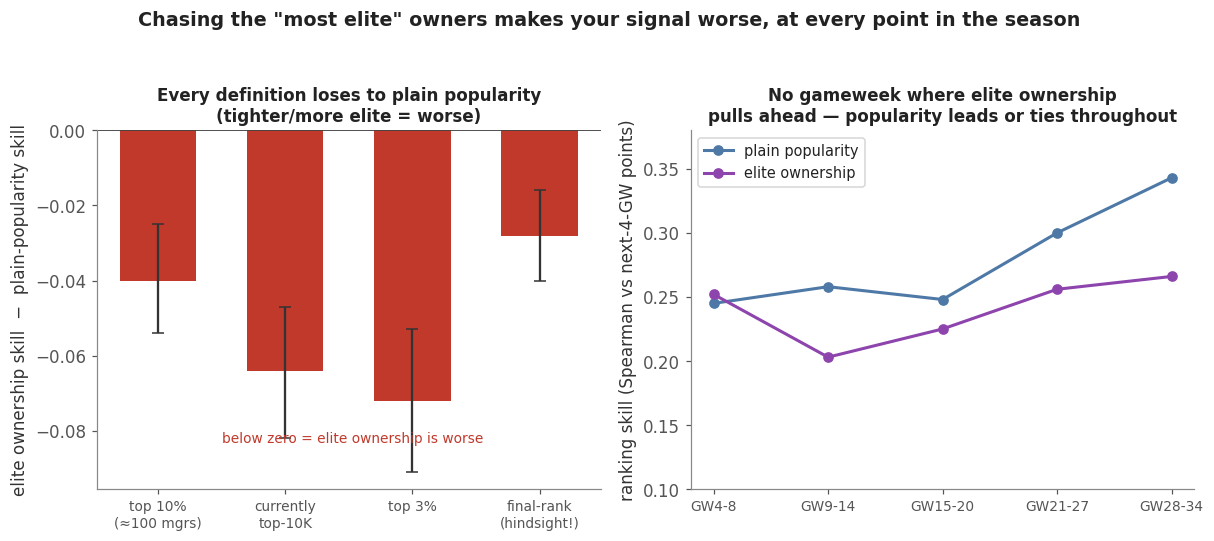

In [7]:
# ---- verified numbers (source: analysis/elite_cohort_eo/eo_sensitivity.py, EO - plain popularity) ----
defs  = ['top 10%\n(≈100 mgrs)', 'currently\ntop-10K', 'top 3%', 'final-rank\n(hindsight!)']
diff  = [-0.040, -0.064, -0.072, -0.028]
dlo   = [-0.054, -0.082, -0.091, -0.040]
dhi   = [-0.025, -0.047, -0.053, -0.016]

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7))
ax = axes[0]
x = np.arange(4)
ax.axhline(0, color='#444', lw=1.2)
ax.bar(x, diff, color=BAD, width=0.6)
ax.errorbar(x, diff, yerr=[np.array(diff)-np.array(dlo), np.array(dhi)-np.array(diff)],
            fmt='none', ecolor='#333', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(defs, fontsize=9)
ax.set_ylabel('elite ownership skill  −  plain-popularity skill')
ax.set_title('Every definition loses to plain popularity\n(tighter/more elite = worse)', fontsize=11)
ax.text(0.5, -0.083, 'below zero = elite ownership is worse', color=BAD, fontsize=9)

# right: flat across the season, EO vs plain popularity by decision-GW block
ax2 = axes[1]
blocks = ['GW4-8', 'GW9-14', 'GW15-20', 'GW21-27', 'GW28-34']
eo_b   = [0.252, 0.203, 0.225, 0.256, 0.266]
own_b  = [0.245, 0.258, 0.248, 0.300, 0.343]
xb = np.arange(5)
ax2.plot(xb, own_b, '-o', color=OWN_C, lw=2, ms=6, label='plain popularity')
ax2.plot(xb, eo_b, '-o', color=EO_C, lw=2, ms=6, label='elite ownership')
ax2.set_xticks(xb); ax2.set_xticklabels(blocks, fontsize=9)
ax2.set_ylabel('ranking skill (Spearman vs next-4-GW points)')
ax2.set_ylim(0.1, 0.38); ax2.legend(fontsize=9.5)
ax2.set_title('No gameweek where elite ownership\npulls ahead — popularity leads or ties throughout', fontsize=11)
fig.suptitle('Chasing the "most elite" owners makes your signal worse, at every point in the season',
             fontsize=12.5, fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('outputs/charts/eo_06_more_elite_worse.png', bbox_inches='tight'); plt.show()

**Reading it:** left — narrowing to the top-3% or the currently-top-10K makes the gap *worse*, because a
smaller, more exclusive group just piles onto the same handful of template players and adds noise. Even
picking the group with **end-of-season hindsight** (the "final-rank" bar) still loses to plain
popularity. Right — across the whole season, plain popularity leads or ties; elite ownership never takes
the lead. There is simply no gameweek at which tracking elite ownership becomes the smarter move.

## The big lesson

**Trust that strong managers are genuinely strong from about Gameweek 6–8 — but do not build your
player shortlist around their ownership.** The bottleneck was never *when* rank settles; it settles
early enough. The problem is that elite ownership just isn't a special signal.

- **The reference group is real early.** By GW6–8 a manager's rank reliably predicts their rank a month
  later, so a "currently strong" group is genuinely skilled, not lucky.
- **But copying their ownership doesn't beat free signals.** Elite ownership (ranking skill ≈ 0.24) is
  beaten by plain popularity (≈ 0.28) in every check, and only barely edges recent points — an edge that
  disappears over an 8-GW window.
- **More elite is worse, not better.** Tightening to the top-3% or top-10K widens the gap; even a
  hindsight-picked "perfect" group loses to plain popularity. The elite mostly own the same popular,
  in-form players everyone owns.

**Recommendation:** don't chase elite ownership as a shortlisting tool. If you want an ownership signal,
plain overall popularity does the same job for free — and recent points among likely starters remains the
simplest, sturdiest guide. Save your effort for the levers that actually move the needle.

---
*Caveats: one season (2025/26). The reference sample is 1,000 managers who all finished ~top 1%
(survivorship) — which should make copying them look **good**, yet it still loses, so the verdict is if
anything generous. "Plain popularity" here means popularity **within that strong-manager sample** (the
data has no global ownership figures), so the precise finding is "narrowing to the most-elite adds nothing
over using the whole strong group." Everything is a **link, not a cause**. Full robustness checks:
analysis/elite_cohort_eo/ (eo_model.py, eo_sensitivity.py) and eo_report.txt.*